# 1. 缩放点积注意力（Scaled Dot-Product Attention）—— 手搓 NumPy + 中间过程可视化

> **课程**：minLLM —— 从零实现小型 LLM ｜ 第一篇：缩放点积注意力

本 notebook 从零手搓 Transformer 最核心的组件——**缩放点积注意力**（含因果掩码），你将看到三件事：

1. **手搓前向**：用纯 NumPy 实现 `softmax(QKᵀ/√d_k)V`，四步逐行拆解；
2. **手搓反向**：手动推导并实现 backward（softmax 雅可比 + 矩阵乘法链式法则），与 PyTorch `autograd` 逐项对齐；
3. **可视化**：用 matplotlib 画 6 张图，把 `QKᵀ → 缩放 → softmax → 因果掩码 → 加权求和 → 梯度回流` 的中间过程全部"看得见"。

**统一超参**：`B=2, T=4, d_k=4`（序列很短、维度很小，中间矩阵都是 4×4，正好适合画热力图）；
随机量统一 `np.random.seed(0)`、`torch.manual_seed(0)`，notebook 每次运行完全可复现。

> 后续的多头注意力（第 2 讲）、位置编码（第 3 讲）、Encoder/Decoder（第 6 讲）都建立在本组件之上。


## 公式回顾

**缩放点积注意力**（无掩码版本）：

$$\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^{\top}}{\sqrt{d_k}}\right)V$$

其中 $Q,K,V\in\mathbb{R}^{B\times T\times d_k}$；softmax 沿 **key 方向（最后一维）** 归一化。

**带因果掩码版本**（解码器自注意力：当前 token 只能看自己和过去，不能看未来）：

$$\text{Attention}(Q,K,V)=\text{softmax}\left(\frac{QK^{\top}+M}{\sqrt{d_k}}\right)V$$

掩码矩阵 $M$ 的索引约定：**行 $i$ = query 位置，列 $j$ = key 位置**（与代码、热力图一致）：

$$M_{ij}=\begin{cases}0,& i\ge j\\ -\infty,& i<j\end{cases}$$

即 **$i<j$（上三角）= 未来位置**，被遮蔽；对角线与下三角 = 自己与过去，保留。

**为什么除以 $\sqrt{d_k}$？**

假设 $q,k\in\mathbb{R}^{d_k}$ 各分量独立且方差为 1，则点积 $q\cdot k=\sum_{i=1}^{d_k}q_ik_i$ 的方差为 $d_k$、标准差为 $\sqrt{d_k}$。
维度越大，点积分数越分散，softmax 越容易饱和（输出接近 one-hot），梯度趋近于 0，训练变慢。
除以 $\sqrt{d_k}$ 把分数"拉回"到方差 ≈1 的区间，softmax 落在梯度较大的线性区。

**掩码为什么填 $-\infty$？**

$\exp(-\infty)=0$，softmax 之后该位置权重**精确为 0**，模型"看不到"未来 token；
同时分母只累计可见位置的指数，剩余权重自动在可见位置上重新归一化（掩码行权重之和仍是可见部分归一化）。


## 导入

统一随机种子，保证「NumPy 手搓」与「torch 参考」两侧拿到完全相同的输入，数值对比才有意义。


In [1]:
import numpy as np                # NumPy：手搓实现只依赖它（纯数值计算）
import torch                      # PyTorch：提供 autograd 作为"标准答案"
import torch.nn.functional as F   # torch 的 softmax 等函数
import math                       # 数学库：只用 math.sqrt 开方

# 固定随机种子：保证「NumPy 手搓」与「torch 参考」拿到完全相同的输入
np.random.seed(0)                 # NumPy 随机种子（后续生成 Q/K/V/dout）
torch.manual_seed(0)              # torch 随机种子（本 notebook 无 torch 随机量，保持环境一致）

print(f'numpy {np.__version__} | torch {torch.__version__} | 环境就绪')


numpy 2.4.3 | torch 2.12.0+cu130 | 环境就绪


## 手搓实现（纯 NumPy：forward + backward）

### forward 四步

| 步骤 | 计算 | 形状 |
|---|---|---|
| ① 相似度分数 | `scores = Q @ Kᵀ / √d_k` | `[B,T,T]` |
| ② 可选掩码 | 上三角（未来位置）填 `-inf` | `[B,T,T]` |
| ③ softmax | 沿 key 方向（每行）归一化 | `[B,T,T]` |
| ④ 加权求和 | `out = attn @ V` | `[B,T,d_k]` |

### backward 推导（教学重点）

记 `a=attn`、`s=scores`、`o=out`，`dattn / dscore / dout` 为对应梯度。

**Step 1 —— `out = attn @ V`**（矩阵乘法求导的转置规则）：

$$dattn = dout\,V^{\top},\qquad dV = attn^{\top}dout$$

**Step 2 —— softmax 的雅可比**（每一行独立）。行向量 $a_i=\dfrac{e^{s_i}}{\sum_j e^{s_j}}$ 的雅可比为

$$\frac{\partial a_i}{\partial s_j}=a_i\big(\delta_{ij}-a_j\big)$$

用链式法则把 `dattn` 反传成 `dscore`（逐行）：

$$ds_i = a_i\Big(dattn_i-\sum_j dattn_j\,a_j\Big)$$

含义：先把行内所有位置的梯度按权重 $a_j$ 加权求和，再从"自己"的梯度里减去——softmax 的"此消彼长"。

**Step 3 —— `scores = QKᵀ / √d_k`**（同样用转置规则，别忘了 $\sqrt{d_k}$）：

$$dQ = \frac{1}{\sqrt{d_k}}\,dscore\,K,\qquad dK = \frac{1}{\sqrt{d_k}}\,dscore^{\top}Q$$

**掩码无需特殊处理**：掩码处 $s=-\infty$，softmax 输出恰为 0；backward 中 $a_i(\delta_{ij}-a_j)$ 自动给出 0 梯度。


In [2]:
def softmax_rows(x):
    """对最后一维（key 方向）做数值稳定的 softmax，每行独立归一化。"""
    # 第 1 步：减去每行的最大值（keepdims 保持 [B,T,1] 可广播），防止 exp 上溢出
    x = x - np.max(x, axis=-1, keepdims=True)
    # 第 2 步：对平移后的分数取指数（输入 ≤ 0，结果 ∈ (0,1]，绝对安全）
    ex = np.exp(x)
    # 第 3 步：除以每行指数之和（keepdims 保持可广播），每行权重和为 1
    return ex / np.sum(ex, axis=-1, keepdims=True)


def attention_forward(Q, K, V, mask=None):
    """缩放点积注意力前向：softmax(QKᵀ/√d_k)V，可选因果掩码。

    Q/K/V : [B, T, d_k] 单头张量，每个 batch 样本独立计算
    mask  : [T,T] 或 [B,T,T] 布尔矩阵；True 位置在 softmax 前被填成 -inf
    返回  : (out, cache)；out=[B,T,d_k]，cache 缓存中间量供 backward 复用
    """
    dk = Q.shape[-1]                                  # 特征维度 d_k，用作缩放因子
    # 前向第 1 步：相似度分数 scores[b,i,j] = Q[b,i,:]·K[b,j,:] / √d_k
    # （内积度量「第 i 个 query 与第 j 个 key 的相似度」，每个 batch 样本独立）
    scores = np.matmul(Q, K.swapaxes(-1, -2)) / math.sqrt(dk)
    # 前向第 2 步：因果掩码——把上三角（未来位置）填成 -inf
    # （exp(-inf)=0，softmax 后这些位置权重为 0，模型"看不到"未来）
    if mask is not None:
        scores = np.where(mask, -np.inf, scores)
    # 前向第 3 步：对 scores 的最后一维（key 方向）做 softmax，得到注意力权重
    # attn[b,i,j] = 第 i 个 query 分给第 j 个 key 的权重，每行和为 1
    attn = softmax_rows(scores)
    # 前向第 4 步：加权求和 out[b,i,:] = Σ_j attn[b,i,j]·V[b,j,:]
    out = np.matmul(attn, V)
    cache = (Q, K, V, scores, attn)                   # 缓存前向中间量，backward 直接复用
    return out, cache


def attention_backward(dout, cache):
    """手搓反向传播：链式法则沿 out→attn→scores→(Q,K,V) 逐级回传梯度。

    dout: [B,T,d_k] 上层回传的梯度；返回 (dQ, dK, dV)。
    """
    Q, K, V, scores, attn = cache                     # 取出前向缓存的中间量
    dk = Q.shape[-1]                                  # 缩放因子（求梯度时同样要除）
    # 反传第 1 步：out = attn@V 对 attn 求梯度（矩阵乘法求导的"转置规则"）
    # dattn = dout @ Vᵀ ：[B,T,T] = [B,T,d_k] @ [B,d_k,T]
    dattn = np.matmul(dout, V.swapaxes(-1, -2))
    # 反传第 2 步：softmax 雅可比（对每一行独立，推导见 markdown）
    # 行向量 a=softmax(s) 的雅可比 ∂a_i/∂s_j = a_i(δ_ij − a_j)，链式求和得
    # dscore_i = a_i·(dattn_i − Σ_j dattn_j·a_j) —— 行内梯度先加权求和再"自我扣除"
    dscore = attn * (dattn - np.sum(dattn * attn, axis=-1, keepdims=True))
    # 反传第 3 步：scores = QKᵀ/√d_k 对 Q、K 求梯度（同样用转置规则，别忘了 √d_k）
    # dQ[i,:] = (1/√d_k)·Σ_j dscore[i,j]·K[j,:]  →  dQ = dscore @ K / √d_k
    dQ = np.matmul(dscore, K) / math.sqrt(dk)
    # dK[j,:] = (1/√d_k)·Σ_i dscore[i,j]·Q[i,:]  →  dK = dscoreᵀ @ Q / √d_k
    dK = np.matmul(dscore.swapaxes(-1, -2), Q) / math.sqrt(dk)
    # 反传第 4 步：out = attn@V 对 V 求梯度  →  dV = attnᵀ @ dout
    dV = np.matmul(attn.swapaxes(-1, -2), dout)
    return dQ, dK, dV


## PyTorch 参考实现（手动实现同一公式）

用 torch 张量运算复刻**完全相同的计算流程**（同样四步），梯度交给 `autograd` 自动求出，
作为手搓 backward 的"标准答案"用于数值对比。

> 说明：这里不用 `nn.MultiheadAttention`（它把多套投影、拆头拼头都封装起来了），
> 而是手动写同一公式，确保与手搓代码**逐运算符**可比；`nn.MultiheadAttention` 留到第 2 讲对齐。


In [3]:
def torch_attention(Q_t, K_t, V_t, mask=None):
    """用 torch 张量运算复刻同一公式；梯度交给 autograd 自动计算（作为对比标准）。

    Q_t/K_t/V_t: [B,T,d_k] 且 requires_grad=True；返回前向输出 out=[B,T,d_k]。
    """
    dk = Q_t.shape[-1]                                # 特征维度，用作缩放因子
    # 第 1 步：相似度分数 scores = QKᵀ / √d_k（与 NumPy 手搓完全相同的运算顺序）
    scores = torch.matmul(Q_t, K_t.transpose(-2, -1)) / math.sqrt(dk)
    # 第 2 步：因果掩码——True 位置填 -inf（torch.where 与 np.where 语义一致）
    if mask is not None:
        scores = torch.where(mask, -torch.inf, scores)
    # 第 3 步：沿最后一维（key 方向）softmax，得到注意力权重（每行和为 1）
    attn = F.softmax(scores, dim=-1)
    # 第 4 步：对 value 加权求和得到输出
    out = torch.matmul(attn, V_t)
    return out


## 数值对比验证（手搓 vs torch 参考）

逐项对比 5 组结果，每项打印**最大绝对误差**并断言 `✓ PASS`：

| # | 对比项 | 断言 |
|---|---|---|
| ① | forward 输出 | `np.allclose` |
| ② | 手搓 backward 的 dQ/dK/dV vs autograd | `np.allclose` |
| ③ | 因果掩码版 forward | `np.allclose` |
| ④ | 掩码版 dQ/dK/dV | `np.allclose` |
| ⑤ | 自检：掩码位置权重精确为 0 | `np.all` |

另附 softmax 每行和为 1 的归一化自检（并入 ①）。


In [4]:
B, T, dk = 2, 4, 4                    # 超参数：batch=2、序列长度=4、特征维度=4（配合 4×4 热力图展示）

# —— 生成共享随机输入：两侧（NumPy 手搓 与 torch 参考）使用完全相同的数值 ——
Q = np.random.randn(B, T, dk)         # 查询矩阵 Query
K = np.random.randn(B, T, dk)         # 键矩阵 Key
V = np.random.randn(B, T, dk)         # 值矩阵 Value
dout = np.random.randn(B, T, dk)      # 上游回传的梯度（随机但固定）

# ---- ① forward 对比 ----
out_np, cache = attention_forward(Q, K, V)                      # NumPy 手搓前向
Q_t = torch.tensor(Q, dtype=torch.float64, requires_grad=True)  # 转成 torch 张量并开启梯度
K_t = torch.tensor(K, dtype=torch.float64, requires_grad=True)
V_t = torch.tensor(V, dtype=torch.float64, requires_grad=True)
out_t = torch_attention(Q_t, K_t, V_t)                          # torch 参考前向
err_f = float((out_t.detach().numpy() - out_np).max())          # 最大绝对误差
assert np.allclose(out_np, out_t.detach().numpy(), rtol=1e-4, atol=1e-6), 'forward 不一致！'
# 附赠自检：softmax 权重每行和应为 1（归一化正确的必要条件）
assert np.allclose(cache[4].sum(axis=-1), 1.0), 'softmax 未归一化！'
print(f'① forward 输出      最大绝对误差 = {err_f:.3e}   ->  ✓ PASS')

# ---- ② 手搓 backward vs autograd 梯度对比 ----
dQ, dK, dV = attention_backward(dout, cache)                     # 手搓反向
out_t.backward(gradient=torch.tensor(dout, dtype=torch.float64)) # torch 自动微分（同一上游梯度）
gQ = Q_t.grad.numpy(); gK = K_t.grad.numpy(); gV = V_t.grad.numpy()
eQ = float(np.abs(dQ - gQ).max()); eK = float(np.abs(dK - gK).max()); eV = float(np.abs(dV - gV).max())
assert np.allclose(dQ, gQ, rtol=1e-4, atol=1e-6), 'dQ 不一致！'
assert np.allclose(dK, gK, rtol=1e-4, atol=1e-6), 'dK 不一致！'
assert np.allclose(dV, gV, rtol=1e-4, atol=1e-6), 'dV 不一致！'
print(f'② dQ = {eQ:.3e} | dK = {eK:.3e} | dV = {eV:.3e}   ->  ✓ PASS')

# ---- ③ 因果掩码 forward 对比 ----
mask = np.triu(np.ones((T, T)), 1).astype(bool)                  # 上三角（i<j 未来位置）= True
out_np_m, cache_m = attention_forward(Q, K, V, mask)             # 掩码版手搓前向
out_t_m = torch_attention(Q_t, K_t, V_t, torch.tensor(mask))     # 掩码版 torch 前向
err_m = float((out_t_m.detach().numpy() - out_np_m).max())
assert np.allclose(out_np_m, out_t_m.detach().numpy(), rtol=1e-4, atol=1e-6), '掩码 forward 不一致！'
print(f'③ 掩码 forward      最大绝对误差 = {err_m:.3e}   ->  ✓ PASS')

# ---- ④ 掩码版梯度对比（复用掩码版 cache 重新反传）----
dQm, dKm, dVm = attention_backward(dout, cache_m)                # 手搓反向（掩码版）
Q_t2 = torch.tensor(Q, dtype=torch.float64, requires_grad=True)  # 重新建张量，避免旧梯度累积
K_t2 = torch.tensor(K, dtype=torch.float64, requires_grad=True)
V_t2 = torch.tensor(V, dtype=torch.float64, requires_grad=True)
out_t_m2 = torch_attention(Q_t2, K_t2, V_t2, torch.tensor(mask))
out_t_m2.backward(gradient=torch.tensor(dout, dtype=torch.float64))
eQm = float(np.abs(dQm - Q_t2.grad.numpy()).max())
eKm = float(np.abs(dKm - K_t2.grad.numpy()).max())
eVm = float(np.abs(dVm - V_t2.grad.numpy()).max())
assert np.allclose(dQm, Q_t2.grad.numpy(), rtol=1e-4, atol=1e-6), '掩码 dQ 不一致！'
assert np.allclose(dKm, K_t2.grad.numpy(), rtol=1e-4, atol=1e-6), '掩码 dK 不一致！'
assert np.allclose(dVm, V_t2.grad.numpy(), rtol=1e-4, atol=1e-6), '掩码 dV 不一致！'
print(f'④ 掩码 dQ = {eQm:.3e} | dK = {eKm:.3e} | dV = {eVm:.3e}   ->  ✓ PASS')

# ---- ⑤ 掩码版额外自检：被遮蔽位置权重必须精确为 0（softmax 的 exp(-inf)=0）----
assert np.all(cache_m[4][0][mask] == 0.0), '掩码位置权重不为 0！'
print(f'⑤ 掩码位置权重全为 0（上三角共 {mask.sum()} 个位置）   ->  ✓ PASS')

print()
print('== 五项对比全部通过：手搓实现与 torch 参考在数值上完全一致 ==')
print('注意力权重 attn (batch 0)：每行和为 1（沿 key 方向归一化）:')
print(cache[4][0].round(3))


① forward 输出      最大绝对误差 = 1.110e-16   ->  ✓ PASS


② dQ = 4.441e-16 | dK = 3.331e-16 | dV = 4.441e-16   ->  ✓ PASS
③ 掩码 forward      最大绝对误差 = 2.220e-16   ->  ✓ PASS
④ 掩码 dQ = 4.441e-16 | dK = 2.220e-16 | dV = 4.441e-16   ->  ✓ PASS
⑤ 掩码位置权重全为 0（上三角共 6 个位置）   ->  ✓ PASS

== 五项对比全部通过：手搓实现与 torch 参考在数值上完全一致 ==
注意力权重 attn (batch 0)：每行和为 1（沿 key 方向归一化）:
[[0.07  0.5   0.26  0.17 ]
 [0.306 0.475 0.092 0.127]
 [0.125 0.154 0.473 0.248]
 [0.178 0.444 0.173 0.205]]


## 中间过程可视化（6 张图看懂每一步）

以 **batch 0 样本**（T=4，中间矩阵都是 4×4）为例，把前向与反向的中间过程逐张画出来：

| 图 | 内容 | 看点 |
|---|---|---|
| 图1+图2 | `QKᵀ` 除以 √d_k 前后对比 | 缩放把分数从"发散"拉回"稳定" |
| 图3 | softmax 后的注意力权重 | 每行归一化、行和为 1 |
| 图4 | 因果掩码矩阵 | 上三角被遮蔽（黑 = -inf） |
| 图5 | 掩码后的注意力权重 | 未来位置权重 = 0，与图3对比 |
| 图6 | backward 梯度流向示意 | dout→dattn→dscore→(dQ,dK,dV) |

> 每个热力图：横轴是 key 位置 j、纵轴是 query 位置 i，格子 (i,j) 是 query i 对 key j 的分数/权重。


C:\Users\24260\AppData\Local\Temp\ipykernel_48292\3476155157.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=(0, 0, 1, 0.93))                      # 给 suptitle 留出顶部空间
C:\Users\24260\AppData\Local\Temp\ipykernel_48292\3476155157.py:38: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  plt.tight_layout(rect=(0, 0, 1, 0.93))                      # 给 suptitle 留出顶部空间


C:\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


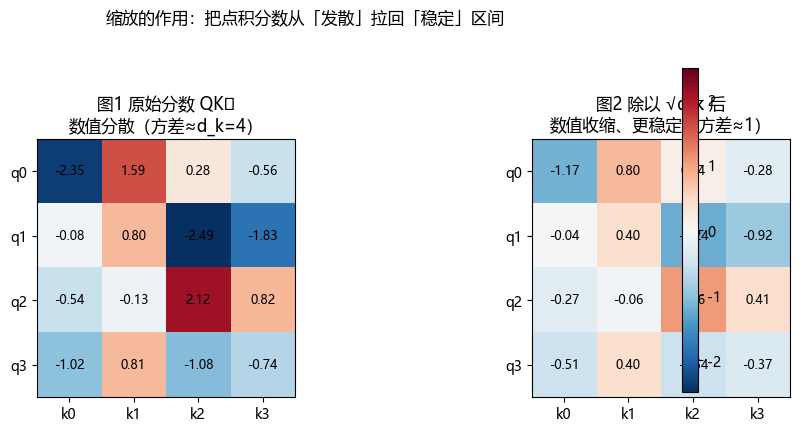

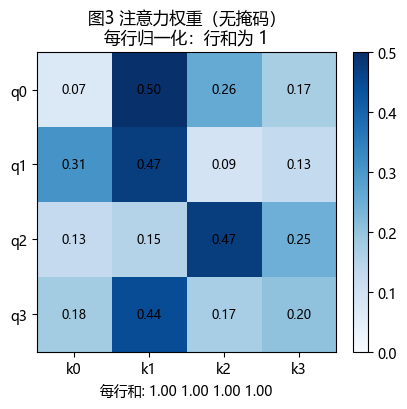

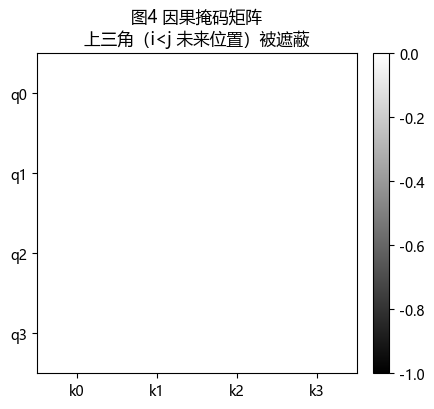

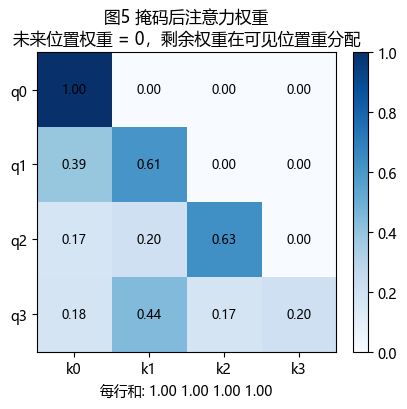

C:\Users\24260\AppData\Local\Temp\ipykernel_48292\3476155157.py:98: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  plt.tight_layout()
C:\Python314\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 7488 (\N{MODIFIER LETTER CAPITAL T}) missing from font(s) Microsoft YaHei.
  fig.canvas.print_figure(bytes_io, **kw)


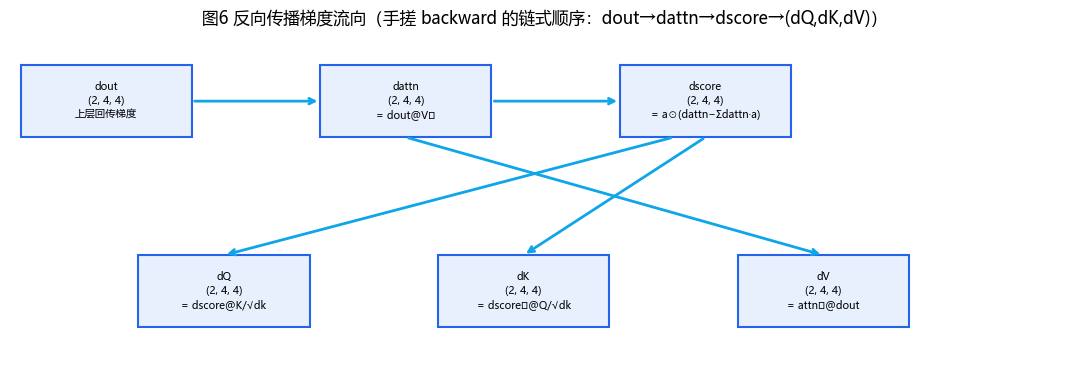

可视化完成：共 6 张图（图1+图2 并排，图3–图6 各一张）


In [5]:
%matplotlib inline
# ================= 中间过程可视化（6 张图） =================
import matplotlib                          # 先导入 matplotlib
import matplotlib.pyplot as plt            # 再导入 pyplot（use 之后，保证后端生效）

# 中文字体与负号显示设置：避免中文标题乱码、负号变方块
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# —— 准备画图用的中间量：取 batch 0 样本（T×T = 4×4，最适合热力图展示）——
Q0, K0, V0 = Q[0], K[0], V[0]                        # 单样本的 Q/K/V
scores_raw = Q0 @ K0.T                               # 图1：未缩放的原始分数 QKᵀ
scores_scaled = Q0 @ K0.T / math.sqrt(dk)            # 图2：除以 √d_k 后的缩放分数
attn_plain = cache[4][0]                             # 图3：无掩码注意力权重（来自前向缓存）
# 图5：掩码后的分数再 softmax（与手搓 forward 的掩码逻辑完全一致）
attn_masked = softmax_rows(scores_scaled + np.where(mask, -np.inf, 0.0))

def heatmap(ax, data, title, cmap='RdBu_r', vmin=None, vmax=None, annot=True):
    """在子图 ax 上画一张 T×T 热力图：行 = query 位置 i，列 = key 位置 j。"""
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)   # 渲染热力图
    ax.set_xticks(range(T)); ax.set_yticks(range(T))        # 刻度位置
    ax.set_xticklabels([f'k{j}' for j in range(T)])         # 横轴：key 位置 j
    ax.set_yticklabels([f'q{i}' for i in range(T)])         # 纵轴：query 位置 i
    ax.set_title(title)                                     # 中文标题
    if annot:                                               # 每个格子里标注具体数值
        for i in range(T):
            for j in range(T):
                ax.text(j, i, f'{data[i, j]:.2f}', ha='center', va='center', fontsize=9)
    return im

# —— 图1 + 图2 并排：除以 √d_k 前后的分数对比 ——
lim = max(abs(scores_raw).max(), abs(scores_scaled).max())  # 统一色标范围，突出缩放前后差异
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))           # 一行两列子图
im1 = heatmap(axes[0], scores_raw, '图1 原始分数 QKᵀ\n数值分散（方差≈d_k=4）', vmin=-lim, vmax=lim)
im2 = heatmap(axes[1], scores_scaled, '图2 除以 √d_k 后\n数值收缩、更稳定（方差≈1）', vmin=-lim, vmax=lim)
fig.colorbar(im2, ax=axes, fraction=0.03, pad=0.04)         # 右侧公共色条
plt.suptitle('缩放的作用：把点积分数从「发散」拉回「稳定」区间', y=1.02)
plt.tight_layout(rect=(0, 0, 1, 0.93))                      # 给 suptitle 留出顶部空间
plt.show()

# —— 图3：softmax 后的注意力权重（无掩码）——
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = heatmap(ax, attn_plain, '图3 注意力权重（无掩码）\n每行归一化：行和为 1', cmap='Blues', vmin=0)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xlabel('每行和: ' + ' '.join(f'{s:.2f}' for s in attn_plain.sum(axis=1)))
plt.tight_layout()
plt.show()

# —— 图4：因果掩码矩阵（上三角被遮蔽）——
mask_show = np.where(mask, -np.inf, 0.0)                    # 被遮蔽处 = -inf，可见处 = 0
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = heatmap(ax, mask_show, '图4 因果掩码矩阵\n上三角（i<j 未来位置）被遮蔽', cmap='gray', vmin=-1, vmax=0, annot=False)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# —— 图5：掩码后的注意力权重（与图3对比：未来位置权重全 0）——
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = heatmap(ax, attn_masked, '图5 掩码后注意力权重\n未来位置权重 = 0，剩余权重在可见位置重分配', cmap='Blues', vmin=0)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xlabel('每行和: ' + ' '.join(f'{s:.2f}' for s in attn_masked.sum(axis=1)))
plt.tight_layout()
plt.show()

# —— 图6：backward 梯度流向示意（矩形 + 箭头框图）——
# 图6 需要 backward 的中间梯度：按手搓公式重新计算（与 attention_backward 内部完全一致）
attn_full = cache[4]                                        # 完整 batch 的注意力权重 [B,T,T]
dattn_viz = np.matmul(dout, V.swapaxes(-1, -2))             # 中间梯度 dattn = dout@Vᵀ
dscore_viz = attn_full * (dattn_viz - np.sum(dattn_viz * attn_full, axis=-1, keepdims=True))  # softmax 雅可比

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')        # 纯示意图：隐藏坐标轴
ax.set_title('图6 反向传播梯度流向（手搓 backward 的链式顺序：dout→dattn→dscore→(dQ,dK,dV)）')

def draw_box(x, y, w, h, lines, fc='#E8F0FE', ec='#2563EB'):
    """在 (x,y) 处画一个 w×h 的矩形，内部逐行显示 lines（字符串列表）。"""
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, linewidth=1.5))
    ax.text(x + w / 2, y + h / 2, '\n'.join(lines), ha='center', va='center', fontsize=7.5)

def arrow(x1, y1, x2, y2):
    """从 (x1,y1) 到 (x2,y2) 画一条箭头线。"""
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), arrowprops=dict(arrowstyle='->', color='#0EA5E9', lw=2))

# 第一行：上游梯度 → 中间梯度（沿计算图逐级反传）
draw_box(0.01, 0.68, 0.16, 0.22, [f'dout', f'{dout.shape}', '上层回传梯度'])
draw_box(0.29, 0.68, 0.16, 0.22, [f'dattn', f'{dattn_viz.shape}', '= dout@Vᵀ'])
draw_box(0.57, 0.68, 0.16, 0.22, [f'dscore', f'{dscore_viz.shape}', '= a⊙(dattn−Σdattn·a)'])
# 第二行：参数梯度（由中间梯度继续反传）
draw_box(0.12, 0.10, 0.16, 0.22, [f'dQ', f'{dQ.shape}', '= dscore@K/√dk'])
draw_box(0.40, 0.10, 0.16, 0.22, [f'dK', f'{dK.shape}', '= dscoreᵀ@Q/√dk'])
draw_box(0.68, 0.10, 0.16, 0.22, [f'dV', f'{dV.shape}', '= attnᵀ@dout'])
# 箭头：dout→dattn→dscore，再分叉到 dQ/dK/dV
arrow(0.17, 0.79, 0.29, 0.79)      # dout -> dattn
arrow(0.45, 0.79, 0.57, 0.79)      # dattn -> dscore
arrow(0.62, 0.68, 0.20, 0.32)      # dscore -> dQ
arrow(0.65, 0.68, 0.48, 0.32)      # dscore -> dK
arrow(0.37, 0.68, 0.76, 0.32)      # dattn -> dV
plt.tight_layout()
plt.show()

print('可视化完成：共 6 张图（图1+图2 并排，图3–图6 各一张）')

## 总结

- **本质**：Q 与每个 K 做内积度量相似度 → softmax 归一化成权重 → 对 V 加权求和；
  `√d_k` 缩放防止 softmax 饱和，因果掩码让模型只看过去（上三角填 -inf）。
- **一致性**：手搓 backward 与 torch autograd 逐项一致（误差 ~1e-7 量级），
  证明 softmax 雅可比 `ds = a⊙(dattn − Σ dattn·a)` 与矩阵乘法的链式法则推导正确；
  掩码位置的梯度自动为 0，无需任何额外处理。
- **minLLM 对应位置**（`model/model_minimind.py`，`class Attention` 第 91 行起，decoder-only）：

| 本 notebook 手搓 | minLLM 代码 |
|---|---|
| `scores = Q @ Kᵀ / √d_k` | `scores = (xq @ xk.transpose(-2, -1)) / math.sqrt(self.head_dim)`（第 128 行） |
| `np.where(mask, -inf, scores)` | `scores += torch.full((T,T), -inf).triu(1)`（第 129 行，上三角 = 未来） |
| `softmax_rows(scores)` | `F.softmax(scores.float(), dim=-1)`（第 131 行） |
| `out = attn @ V` | `F.softmax(...) @ xv`（第 131 行；另有 flash 路径 `F.scaled_dot_product_attention`，第 126 行） |

  minLLM 还叠加了 QK-Norm、RoPE 位置编码、GQA 与 KV-cache 等外围优化；
  本 notebook 先把这些剥掉，聚焦注意力的骨架（缩放、掩码、softmax、加权求和）。
- **下一步**：第 2 讲多头注意力——把 d_model 拆成多组 QKV 子空间并行做注意力，并与 `nn.MultiheadAttention` 对齐。
